# Exercise 2 - In this exercise, you may use built-in procedures for generating random numbers.

Compare the results obtained from simulation with the corresponding theoretical results.

Use histograms and statistical tests where appropriate.


## Part 1

Choose a value for the probability parameter $(p)$ in the geometric distribution and simulate 10,000 observations.

- Compare the simulated and theoretical distributions. You should experiment with small, moderate, and large values of $p$.

For this part, we simulate observations from a geometric distribution. We do this because the exercise asks us to compare simulated results with the theoretical distribution. In the course notes, the goal is to generate random variables with a given distribution, using random numbers from $U(0,1)$ as the starting point. The notes also show that for a geometric distribution,

$P(X = n) = (1-p)^{n-1}p$

and

$F(n) = P(X \leq n) = 1 - (1-p)^n$.

Using the direct method, the geometric random variable can be generated as

$X = \left\lfloor \frac{\log(U)}{\log(1-p)} \right\rfloor + 1$,

where $U \sim U(0,1)$.

In this exercise, I use three different values of $p$:

- small value: $p = 0.2$
- moderate value: $p = 0.5$
- large value: $p = 0.8$

This is done to see how the distribution changes when the probability of success changes. A small value of $p$ gives larger waiting times, while a large value of $p$ gives smaller waiting times.


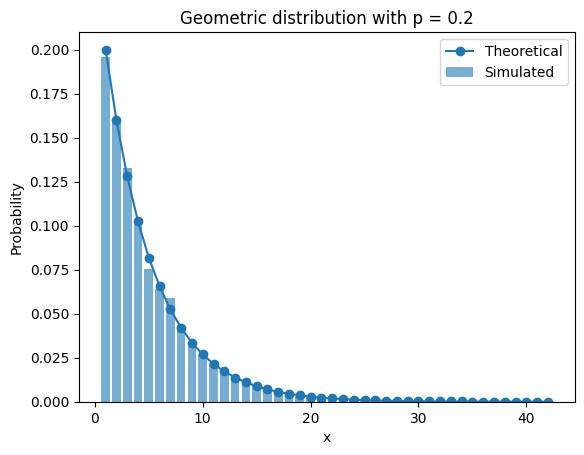

p = 0.2
Simulated mean: 5.0184
Theoretical mean: 5.0



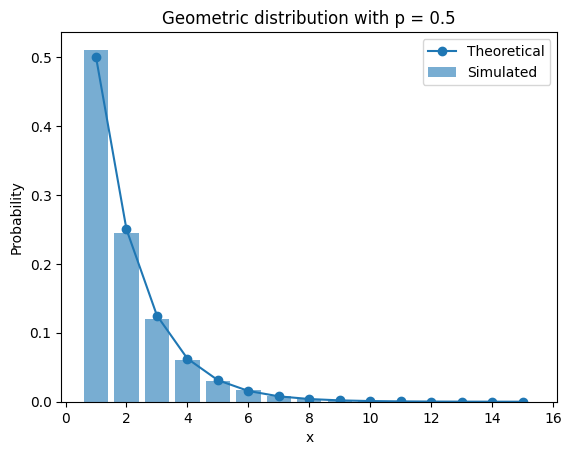

p = 0.5
Simulated mean: 1.9922
Theoretical mean: 2.0



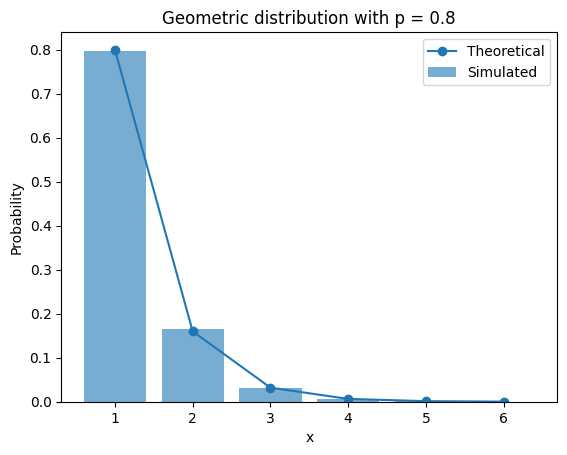

p = 0.8
Simulated mean: 1.2513
Theoretical mean: 1.25



In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Number of observations
n = 10000

# Different values of p
p_values = [0.2, 0.5, 0.8]

for p in p_values:
    
    # Generate uniform random numbers
    U = np.random.random(n)
    
    # Generate geometric random variables
    X = np.floor(np.log(U) / np.log(1 - p)) + 1
    
    # Make X integer
    X = X.astype(int)
    
    # Values for theoretical probabilities
    x_values = np.arange(1, max(X) + 1)
    theoretical_probs = (1 - p)**(x_values - 1) * p
    
    # Simulated probabilities
    simulated_probs = []
    
    for x in x_values:
        simulated_probs.append(np.mean(X == x))
    
    # Plot simulated and theoretical distribution
    plt.figure()
    plt.bar(x_values, simulated_probs, alpha=0.6, label="Simulated")
    plt.plot(x_values, theoretical_probs, marker="o", label="Theoretical")
    plt.xlabel("x")
    plt.ylabel("Probability")
    plt.title("Geometric distribution with p = " + str(p))
    plt.legend()
    plt.show()
    
    # Compare simulated and theoretical mean
    simulated_mean = np.mean(X)
    theoretical_mean = 1 / p
    
    print("p =", p)
    print("Simulated mean:", round(simulated_mean, 4))
    print("Theoretical mean:", round(theoretical_mean, 4))
    print()

## Part 2

Consider the six-point distribution

| $x_i$ | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---:|---:|---:|---:|---:|---:|
| $\mathbb{P}(X = x_i)$ | $\frac{7}{48}$ | $\frac{5}{48}$ | $\frac{1}{8}$ | $\frac{1}{16}$ | $\frac{1}{4}$ | $\frac{5}{16}$ |

Generate observations from this distribution using:

1. the direct (crude) method,
2. the rejection method,
3. the alias method.

For this part, we generate observations from the six-point distribution

| $x_i$ | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---:|---:|---:|---:|---:|---:|
| $P(X = x_i)$ | $\frac{7}{48}$ | $\frac{5}{48}$ | $\frac{1}{8}$ | $\frac{1}{16}$ | $\frac{1}{4}$ | $\frac{5}{16}$ |

We do this because the exercise asks us to generate observations from the same discrete distribution using three different methods: the direct method, the rejection method, and the alias method. The course notes explain that the direct method uses intervals from the cumulative probabilities, the rejection method accepts or rejects proposed values, and the alias method uses preprocessing to make the simulation step very efficient.

The probabilities are
$$
p = \left(\frac{7}{48}, \frac{5}{48}, \frac{1}{8}, \frac{1}{16}, \frac{1}{4}, \frac{5}{16}\right)
$$

We simulate $n = 10000$ observations from the distribution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

# Values and probabilities
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

n = 10000

### Direct method

The direct method uses the cumulative probabilities. We generate $U \sim U(0,1)$ and find the interval where $U$ falls.

In [3]:
# Direct method

cdf = np.cumsum(p)

U = np.random.random(n)

samples_direct = np.zeros(n, dtype=int)

for i in range(n):
    for j in range(len(cdf)):
        if U[i] <= cdf[j]:
            samples_direct[i] = x[j]
            break

### Rejection method

The rejection method first proposes a value uniformly from ${1,2,3,4,5,6}$. Then it accepts the value with probability $\frac{p_I}{c}$, where $c = \max_i p_i$.

In [4]:
# Rejection method

samples_rejection = []

c = max(p)

while len(samples_rejection) < n:
    
    U1 = np.random.random()
    U2 = np.random.random()
    
    I = int(np.floor(6 * U1))
    
    if U2 <= p[I] / c:
        samples_rejection.append(x[I])

samples_rejection = np.array(samples_rejection)

### Alias method

The alias method first builds two tables. This makes the setup more complicated, but after that each observation is generated very fast.

In [5]:
# Alias method

k = len(p)

q = k * p.copy()
alias = np.zeros(k, dtype=int)

small = []
large = []

for i in range(k):
    if q[i] < 1:
        small.append(i)
    else:
        large.append(i)

while len(small) > 0 and len(large) > 0:
    
    s = small.pop()
    l = large.pop()
    
    alias[s] = l
    
    q[l] = q[l] - (1 - q[s])
    
    if q[l] < 1:
        small.append(l)
    else:
        large.append(l)

U1 = np.random.random(n)
U2 = np.random.random(n)

I = np.floor(k * U1).astype(int)

samples_alias = np.zeros(n, dtype=int)

for i in range(n):
    if U2[i] <= q[I[i]]:
        samples_alias[i] = I[i] + 1
    else:
        samples_alias[i] = alias[I[i]] + 1

### Comparing the simulated probabilities

In [6]:
# Compare simulated probabilities with theoretical probabilities

methods = {
    "Direct method": samples_direct,
    "Rejection method": samples_rejection,
    "Alias method": samples_alias
}

for name, samples in methods.items():
    
    print(name)
    
    for value in x:
        simulated_probability = np.mean(samples == value)
        theoretical_probability = p[value - 1]
        
        print(
            "x =", value,
            "simulated =", round(simulated_probability, 4),
            "theoretical =", round(theoretical_probability, 4)
        )
    
    print()

Direct method
x = 1 simulated = 0.1462 theoretical = 0.1458
x = 2 simulated = 0.1077 theoretical = 0.1042
x = 3 simulated = 0.1226 theoretical = 0.125
x = 4 simulated = 0.0591 theoretical = 0.0625
x = 5 simulated = 0.2565 theoretical = 0.25
x = 6 simulated = 0.3079 theoretical = 0.3125

Rejection method
x = 1 simulated = 0.1466 theoretical = 0.1458
x = 2 simulated = 0.1051 theoretical = 0.1042
x = 3 simulated = 0.1257 theoretical = 0.125
x = 4 simulated = 0.0671 theoretical = 0.0625
x = 5 simulated = 0.2464 theoretical = 0.25
x = 6 simulated = 0.3091 theoretical = 0.3125

Alias method
x = 1 simulated = 0.1467 theoretical = 0.1458
x = 2 simulated = 0.1047 theoretical = 0.1042
x = 3 simulated = 0.1252 theoretical = 0.125
x = 4 simulated = 0.0659 theoretical = 0.0625
x = 5 simulated = 0.2485 theoretical = 0.25
x = 6 simulated = 0.309 theoretical = 0.3125



### Histogram plots

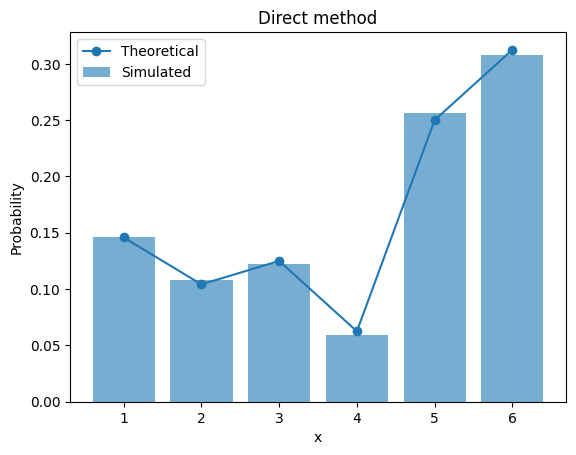

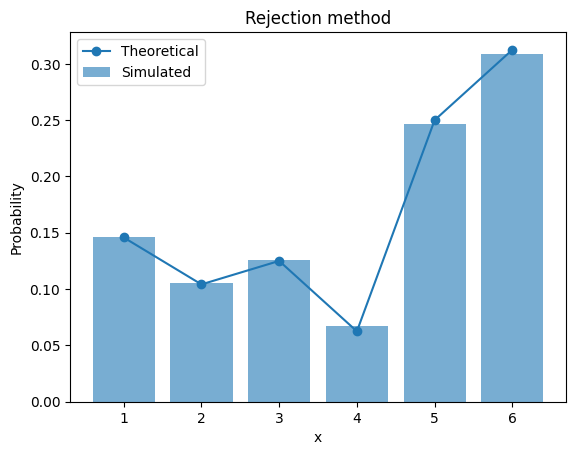

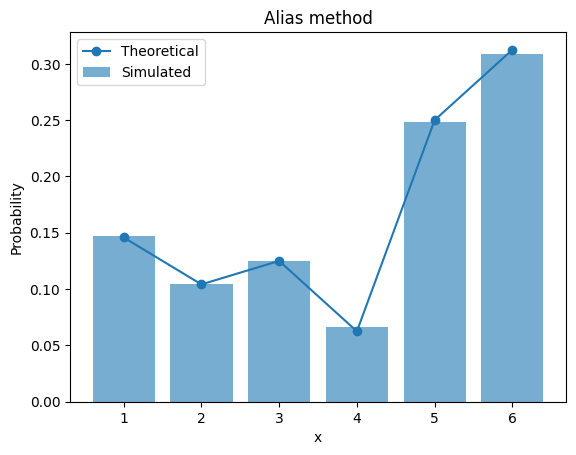

In [7]:
# Plot histograms

for name, samples in methods.items():
    
    simulated_probs = []
    
    for value in x:
        simulated_probs.append(np.mean(samples == value))
    
    plt.figure()
    plt.bar(x, simulated_probs, alpha=0.6, label="Simulated")
    plt.plot(x, p, marker="o", label="Theoretical")
    plt.xlabel("x")
    plt.ylabel("Probability")
    plt.title(name)
    plt.legend()
    plt.show()

## Part 3

Compare the three generation methods using appropriate performance measures and discuss the results.

Possible criteria include:

- Computational efficiency
- Ease of implementation
- Memory requirements
- Accuracy of the generated distribution


For this part, we compare the three generation methods from Part 2: the direct method, the rejection method, and the alias method. We do this because the exercise asks us to compare the methods using performance measures such as computational efficiency, ease of implementation, memory requirements, and accuracy of the generated distribution. The course notes also state that simulation results should be compared with the corresponding theoretical results using histograms and statistical tests where appropriate. :contentReference[oaicite:0]{index=0}

The target distribution is

| $x_i$ | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---:|---:|---:|---:|---:|---:|
| $P(X = x_i)$ | $\frac{7}{48}$ | $\frac{5}{48}$ | $\frac{1}{8}$ | $\frac{1}{16}$ | $\frac{1}{4}$ | $\frac{5}{16}$ |

To compare the accuracy, we calculate the simulated probabilities $\hat{p}_i$ and compare them with the theoretical probabilities $p_i$. A simple error measure is

$$
\max_i |\hat{p}_i - p_i|
$$

We also measure the running time of each method.

In [8]:
import numpy as np
import time

np.random.seed(1)

# Values and probabilities
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

n = 10000

### Direct method

In [9]:
start = time.time()

cdf = np.cumsum(p)
U = np.random.random(n)

samples_direct = np.zeros(n, dtype=int)

for i in range(n):
    for j in range(len(cdf)):
        if U[i] <= cdf[j]:
            samples_direct[i] = x[j]
            break

time_direct = time.time() - start

### Rejection method

In [10]:
start = time.time()

samples_rejection = []
c = max(p)

while len(samples_rejection) < n:
    
    U1 = np.random.random()
    U2 = np.random.random()
    
    I = int(np.floor(6 * U1))
    
    if U2 <= p[I] / c:
        samples_rejection.append(x[I])

samples_rejection = np.array(samples_rejection)

time_rejection = time.time() - start

### Alias method

In [11]:
start = time.time()

k = len(p)

q = k * p.copy()
alias = np.zeros(k, dtype=int)

small = []
large = []

for i in range(k):
    if q[i] < 1:
        small.append(i)
    else:
        large.append(i)

while len(small) > 0 and len(large) > 0:
    
    s = small.pop()
    l = large.pop()
    
    alias[s] = l
    q[l] = q[l] - (1 - q[s])
    
    if q[l] < 1:
        small.append(l)
    else:
        large.append(l)

U1 = np.random.random(n)
U2 = np.random.random(n)

I = np.floor(k * U1).astype(int)

samples_alias = np.zeros(n, dtype=int)

for i in range(n):
    if U2[i] <= q[I[i]]:
        samples_alias[i] = I[i] + 1
    else:
        samples_alias[i] = alias[I[i]] + 1

time_alias = time.time() - start


### Compare methods

In [12]:
methods = {
    "Direct": samples_direct,
    "Rejection": samples_rejection,
    "Alias": samples_alias
}

times = {
    "Direct": time_direct,
    "Rejection": time_rejection,
    "Alias": time_alias
}

print("Method       Time       Max absolute error")
print("------------------------------------------")

for name, samples in methods.items():
    
    simulated_probs = []
    
    for value in x:
        simulated_probs.append(np.mean(samples == value))
    
    simulated_probs = np.array(simulated_probs)
    max_error = np.max(np.abs(simulated_probs - p))
    
    print(name, "   ", round(times[name], 5), "   ", round(max_error, 5))

Method       Time       Max absolute error
------------------------------------------
Direct     0.00564     0.0065
Rejection     0.0239     0.0046
Alias     0.00374     0.0035


## Part 4

Provide recommendations regarding when each method should be preferred.

Discuss the advantages and disadvantages of the:

- Direct (crude) method
- Rejection method
- Alias method

If time permits, support your conclusions through additional simulation experiments.

For this part, we discuss when each method should be preferred. We do this because Part 4 asks us to compare the advantages and disadvantages of the direct method, the rejection method, and the alias method. In the course notes, the direct method is based on cumulative probabilities, the rejection method uses accept/reject sampling, and the alias method is described as very efficient during simulation but with a more complicated preprocessing step. `:contentReference[oaicite:0]{index=0}`

### Direct method

The direct method should be preferred when the distribution is small or when we only need to generate a limited number of observations.

The method is based on the cumulative probabilities. We generate $U \sim U(0,1)$ and choose the value $x_i$ where

$$
\sum_{j=1}^{i-1} p_j < U \leq \sum_{j=1}^{i} p_j
$$

#### Advantages

- Easy to understand.
- Easy to implement.
- Requires little memory.
- Works well for small distributions.

#### Disadvantages


- Can become slower when there are many possible outcomes.
- If a linear search is used, the algorithm may have to check many intervals before finding the correct one.

For this exercise, the direct method is a good choice because the distribution only has six possible outcomes.

### Rejection method

The rejection method should be preferred when it is easy to sample from a proposal distribution and when the acceptance probability is high.

In this exercise, we propose a value uniformly from $\{1,2,3,4,5,6\}$ and accept it with probability

$$\frac{p_I}{c}$$

where $c = \max_i p_i$.

#### Advantages

- Relatively simple to implement.
- Does not require cumulative probabilities.
- Can be useful when direct inversion is difficult.

#### Disadvantages

- Can be inefficient if many proposed values are rejected.
- The running time is random because we do not know how many proposals are needed.
- It may require more random numbers than the direct and alias methods.

For this distribution, the rejection method works, but it is not the best method because some proposed values are rejected.


### Alias method

The alias method should be preferred when we need to generate many observations from the same discrete distribution.

The method first builds alias tables. After preprocessing, each observation can be generated using a random index, one comparison, and possibly one table lookup.


#### Advantages

- Very fast after preprocessing.
- Efficient for large numbers of simulations.
- Good when the same distribution is used many times.

#### Disadvantages

- More difficult to implement.
- Requires extra memory for the alias tables.
- The preprocessing step is unnecessary if only a few observations are needed.

For this exercise, the alias method works well, but it is more complicated than necessary because the distribution only has six outcomes.

### Final recommendation

For the six-point distribution in this exercise, the **direct method** is the best overall choice because it is simple, accurate, and fast enough.

The **rejection method** is useful as an alternative, but it is less efficient because some generated values are rejected.

The **alias method** is the best choice if we need to generate a very large number of observations from the same distribution. However, for this small example, the extra implementation work is not really needed.

Overall:

| Method | Best used when |
|---|---|
| Direct method | The distribution is small and simplicity is important |
| Rejection method | A good proposal distribution is available and the acceptance rate is high |
| Alias method | Many observations are needed from the same distribution |